In [1]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("hospital_patient_dataset.csv")
df

,patient_id,age,gender,blood_pressure,cholesterol,bmi,department
0,1,3,male,155,155.6,36.9,orthopedics
1,2,4,male,122,201.5,23.4,general
2,3,45,female,140,212.0,NaN,cardiology
3,4,19,female,126,121.1,16.9,orthopedics
4,5,94,female,108,273.7,16.2,general
...,...,...,...,...,...,...,...
1515,1165,26,female,116,242.1,20.4,neurology
1516,1241,78,male,100,237.1,38.5,general
1517,541,30,female,155,167.7,23.4,general
1518,630,77,male,100,288.9,27.6,neurology


In [2]:
df.shape

(1520, 7)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1520 entries, 0 to 1519
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   patient_id      1520 non-null   int64  
 1   age             1520 non-null   int64  
 2   gender          1520 non-null   str    
 3   blood_pressure  1520 non-null   int64  
 4   cholesterol     1449 non-null   float64
 5   bmi             1470 non-null   float64
 6   department      1520 non-null   str    
dtypes: float64(2), int64(3), str(2)
memory usage: 104.1 KB


In [4]:
df.describe()

,patient_id,age,blood_pressure,cholesterol,bmi
count,1520.000000,1520.000000,1520.000000,1449.000000,1470.000000
mean,750.461842,45.759868,125.498026,210.092202,27.519796
std,432.738022,27.100444,22.607508,51.872495,7.256358
min,1.000000,1.000000,90.000000,120.000000,15.000000
25%,377.750000,22.000000,108.000000,164.700000,21.200000
50%,749.500000,44.000000,125.000000,208.500000,27.500000
75%,1126.250000,69.000000,142.000000,253.800000,33.900000
max,1500.000000,94.000000,279.000000,300.000000,40.000000


In [5]:
df.duplicated().sum()

np.int64(20)

In [6]:
df.isnull().sum()

patient_id         0
age                0
gender             0
blood_pressure     0
cholesterol       71
bmi               50
department         0
dtype: int64

In [7]:
no_rows = df.shape[0]
null_value_count = df.isnull().sum().to_list()
columns_df = df.columns.to_list()

for column, count in zip(columns_df, null_value_count):
    print(f'null percentage {column}: {count / no_rows * 100:.2f}%')

null percentage patient_id: 0.00%
null percentage age: 0.00%
null percentage gender: 0.00%
null percentage blood_pressure: 0.00%
null percentage cholesterol: 4.67%
null percentage bmi: 3.29%
null percentage department: 0.00%


In [8]:
# drop the duplicate rows
df=df.drop_duplicates()
df.shape

(1500, 7)

In [9]:
# fill missing cholesterol with the median
cholesterol_median = df['cholesterol'].median()
df['cholesterol'] = df['cholesterol'].fillna(cholesterol_median)

In [10]:
# fill missing bmi with the median
bmi_median = df['bmi'].median()
df['bmi'] = df['bmi'].fillna(bmi_median)

In [11]:
df.isnull().sum()

patient_id        0
age               0
gender            0
blood_pressure    0
cholesterol       0
bmi               0
department        0
dtype: int64

In [12]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['gender']=le.fit_transform(df['gender'])

In [13]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['department']=le.fit_transform(df['department'])

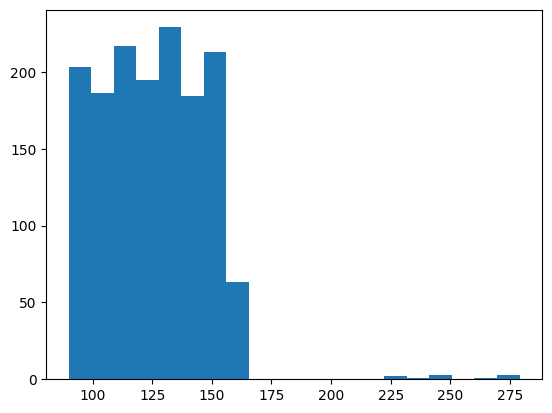

In [14]:
# histogram to see the distribution
plt.hist(x=df['blood_pressure'],bins=20)
plt.show()

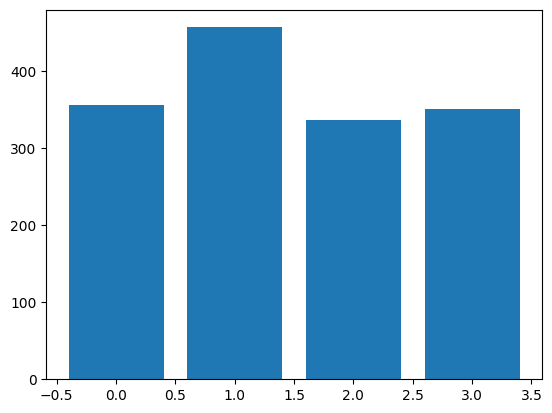

In [15]:
# bar chart
plt.bar(x=df['department'].value_counts().index,height=df['department'].value_counts().values)
plt.show()

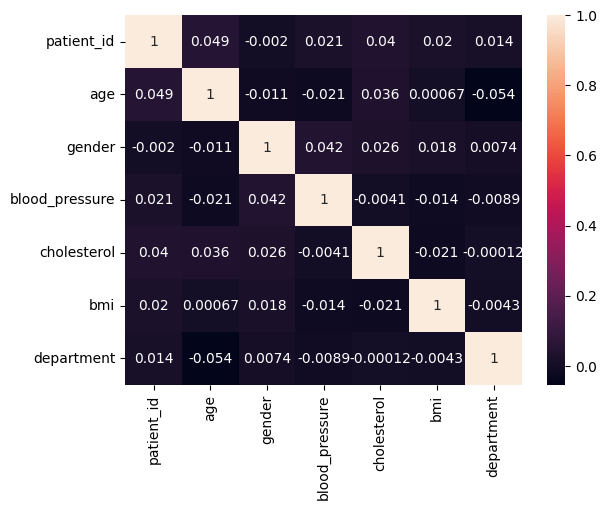

In [16]:
# correlation heatmap
sns.heatmap(df.corr(),annot=True)
plt.show()

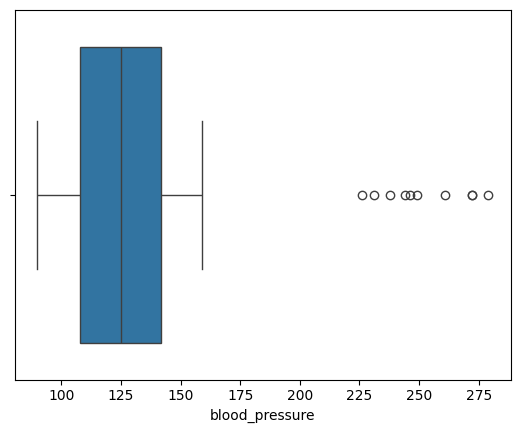

In [17]:
# boxplot to spot outliers in blood_pressure
sns.boxplot(x=df['blood_pressure'])
plt.show()

In [18]:
# identify outliers using the IQR method
Q1 = df['blood_pressure'].quantile(0.25)
Q3 = df['blood_pressure'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['blood_pressure'] < lower_bound) | (df['blood_pressure'] > upper_bound)]
outliers

,patient_id,age,gender,blood_pressure,cholesterol,bmi,department
245,246,8,0,244,290.9,30.7,2
499,500,26,0,238,154.1,36.5,1
501,502,65,1,249,255.4,27.5,2
921,922,23,0,226,173.2,15.9,0
1001,1002,52,0,261,195.6,18.2,1
1095,1096,87,1,272,167.8,39.3,0
1120,1121,60,0,279,284.1,39.6,0
1138,1139,93,1,272,121.6,19.7,0
1243,1244,2,1,231,120.0,28.6,1
1261,1262,40,0,246,128.1,36.2,1


In [19]:
# remove the outliers
df = df[(df['blood_pressure'] >= lower_bound) & (df['blood_pressure'] <= upper_bound)]
df.shape

(1490, 7)